In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
results = pd.concat([pd.read_csv(f).assign(file=f) for f in glob.glob("results/mean*.csv")]).assign(
    configuration=lambda df: df["file"].apply(lambda row: row[-9:-8]),
    scenario=lambda df: df["file"].apply(lambda row: row[-7:-6]),
    noise_level=lambda df: df["file"].apply(lambda row: row[-5:-4])
)

In [3]:
results

,Best model,All models,Rashomon,Best of Family,Best of Family models ∩ Rashomon models,file,configuration,scenario,noise_level
0,0.467340,1.244417,1.036562,1.599908,0.787173,results/mean_distance_to_gt_pdp_A_1_1.csv,A,1,1
1,0.036443,0.083408,0.046357,0.046350,0.049607,results/mean_distance_to_gt_pdp_A_1_1.csv,A,1,1
2,0.155628,0.175598,0.149808,0.129725,0.116817,results/mean_distance_to_gt_pdp_A_1_1.csv,A,1,1
3,0.067221,0.062767,0.056561,0.060871,0.052817,results/mean_distance_to_gt_pdp_A_1_1.csv,A,1,1
4,0.134145,0.132159,0.096331,0.065734,0.074981,results/mean_distance_to_gt_pdp_A_1_1.csv,A,1,1
...,...,...,...,...,...,...,...,...,...
4,0.433421,0.267691,0.260796,0.074150,0.120348,results/mean_distance_to_gt_pdp_M_2_9.csv,M,2,9
5,0.061663,0.064618,0.070600,0.105440,0.117186,results/mean_distance_to_gt_pdp_M_2_9.csv,M,2,9
6,0.295533,0.322420,0.302689,0.268379,0.349838,results/mean_distance_to_gt_pdp_M_2_9.csv,M,2,9
7,0.027581,0.024263,0.025123,0.045925,0.062021,results/mean_distance_to_gt_pdp_M_2_9.csv,M,2,9


In [4]:
results.describe()

,Best model,All models,Rashomon,Best of Family,Best of Family models ∩ Rashomon models
count,378.000000,378.000000,378.000000,378.000000,378.000000
mean,0.176989,0.219340,0.176338,0.219439,0.178231
std,0.229669,0.268802,0.233498,0.348947,0.242463
min,0.002437,0.008551,0.009718,0.004465,0.007569
25%,0.047978,0.064716,0.055078,0.047399,0.053147
50%,0.091325,0.146399,0.097975,0.102915,0.099680
75%,0.219958,0.243853,0.193321,0.192776,0.194802
max,1.606778,1.546711,1.418844,2.011933,1.630302


In [5]:
results.groupby("configuration")[results.columns[:-4]].mean().style.highlight_min(axis=1)

,Best model,All models,Rashomon,Best of Family,Best of Family models ∩ Rashomon models
configuration,,,,,
A,0.191706,0.197307,0.178127,0.223753,0.177288
B,0.162519,0.229526,0.174943,0.209273,0.169229
C,0.166372,0.228222,0.169585,0.205469,0.167681
D,0.160739,0.229459,0.173299,0.206635,0.169827
M,0.216919,0.208608,0.190439,0.268374,0.221583


In [6]:
results.groupby("scenario")[results.columns[:-4]].mean().style.highlight_min(axis=1)

,Best model,All models,Rashomon,Best of Family,Best of Family models ∩ Rashomon models
scenario,,,,,
1,0.204272,0.290972,0.218963,0.274696,0.223013
2,0.170183,0.190178,0.155048,0.212986,0.159835
3,0.151394,0.166253,0.149670,0.158432,0.145250


In [7]:
results.groupby("noise_level")[results.columns[:-4]].mean().style.highlight_min(axis=1)

,Best model,All models,Rashomon,Best of Family,Best of Family models ∩ Rashomon models
noise_level,,,,,
1,0.123020,0.198125,0.127736,0.185093,0.120970
4,0.178313,0.228365,0.187433,0.236688,0.202614
9,0.229634,0.231529,0.213846,0.236535,0.211111


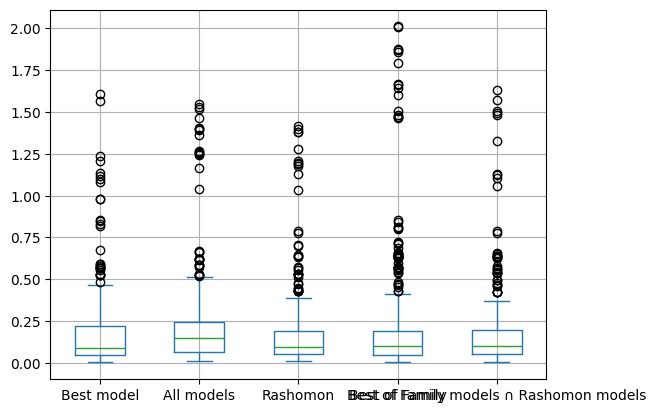

In [8]:
results[results.columns[:-4]].plot.box()
plt.grid()


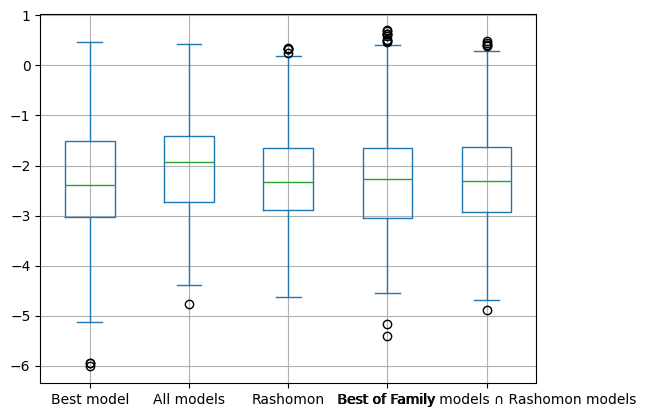

In [9]:
results[results.columns[:-4]].apply(np.log).plot.box()
plt.grid()
